In [1]:
import os
import sys
import anndata as ad
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import gseapy as gp
import anndata as ad
import statistics
import tempfile
import sklearn
import cosg
import leidenalg
import celltypist
import muon as mu
from tqdm import tqdm
sc._settings.n_jobs= 24
sc.settings.verbosity = 1
# Adjust Scanpy figure defaults
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
import warnings
warnings.filterwarnings('ignore')

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup==False:
        return '无重复'
    else:
        return '有重复'

In [3]:
obj_path = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R3/'

In [4]:
finnal_path = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Finnal/'

In [5]:
leiden_groups=['L4_leiden_TOTALVI_0.1','L4_leiden_TOTALVI_0.5', 'L4_leiden_TOTALVI_1', 'L4_leiden_TOTALVI_1.5', 'L4_leiden_TOTALVI_0.3','L4_leiden_TOTALVI_0.8']

In [6]:
def get_annotation_data(celltype):
    adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_count_scRNA.h5ad",backed='r')
    adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
    adata.obsm = adt.obsm
    
    # read Level1, tcr, bcr infor
    indices = pd.read_csv(f'{obj_path}/{celltype}/R3_indices_{celltype}.csv',index_col=0)
    # join leiden groups
    leiden_data = adt.obs.loc[:,leiden_groups]
    adata.obs = adata.obs.join(indices, how='left')
    adt.obs = adt.obs.join(indices, how='left')
    adata.obs = adata.obs.join(leiden_data, how='left')
    adata.strings_to_categoricals()
    return adata,adt,leiden_data

In [7]:
def get_norm_annotation_data(celltype):
    adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_count_scRNA.h5ad")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
    adata.obsm = adt.obsm
    
    # read Level1, tcr, bcr infor
    indices = pd.read_csv(f'{obj_path}/{celltype}/R3_indices_{celltype}.csv',index_col=0)
    # join leiden groups
    leiden_data = adt.obs.loc[:,leiden_groups]
    adata.obs = adata.obs.join(indices, how='left')
    adt.obs = adt.obs.join(indices, how='left')
    adata.obs = adata.obs.join(leiden_data, how='left')
    return adata,adt,leiden_data

# 1. 定 终 NaiveB Cell Refine

In [8]:
celltype="NaiveB"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [9]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4)

In [10]:
groupby = "L4_leiden_TOTALVI_0.3"

In [56]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [58]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IGHM',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='IGHD',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'IGHM',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'IGHD',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'CD27',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'ETV6',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.violin(adata,'FCER2',groupby=groupby,size=0)

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','CR2','CD5','MS4A1',
    'TNFRSF13C','CD24','C1QC','C1QA','CD93',
                      'FCRL4','CD180','IL2RA',
                      'BACH2','PAX5',
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                     'AIM2','CD27','IGHA1','IGHA2','ENTPD1','LAIR1','CD72',
#DEG                     
                     'NT5E','AREG','ITGB1','MS4A1'],
              standard_scale='obs',groupby=groupby)

In [11]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
1    445557
4    244197
0    152206
3    102632
6     58800
2     20109
5     13205
Name: count, dtype: int64

In [12]:
cell_dict = {
             #Naïve B,TCL1A, IL4R,FCER2,. CD19+, CD20+, CD27-, IgD+, IgM+,
             'Naïve B cells':['0','1','2','3','4','5','6'],
            }

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [13]:
check_dict_duplicates(cell_dict)

'无重复'

In [14]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [15]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    1036706
Name: count, dtype: int64

In [16]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Naïve B cells    1036706
Name: count, dtype: int64

In [18]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,Celltype_L3_L4_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_AAACATCG_GCTCGGTA_AGATCGCA,B|Plasma,Naïve B,Naïve B,Naïve B cells,NaiveB c0,NaN,BCR,1.135809,7.090641
D0589_Rep1_ATCATTCC_AAGACGGA_CCATCCTC,B|Plasma,Naïve B,Naïve B,Naïve B cells,NaiveB c0,NaN,BCR,-1.427694,6.078983
D0589_Rep1_AGATCGCA_CAATGGAA_AAGGTACA,B|Plasma,Naïve B,Naïve B,Naïve B cells,NaiveB c1,NaN,BCR,0.423818,4.391290
D0589_Rep1_AGCCATGC_AGTACAAG_CAACCACA,B|Plasma,Naïve B,Naïve B,Naïve B cells,NaiveB c1,NaN,BCR,-0.510754,5.995306
D0589_Rep1_CCTAATCC_CAAGGAGC_CTGAGCCA,B|Plasma,Naïve B,Naïve B,Naïve B cells,NaiveB c4,NaN,BCR,4.630273,7.177624


# 2. 定 终 Memory B Cell Refine

In [19]:
celltype="Memory_B"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [20]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4)

In [21]:
groupby = "L4_leiden_TOTALVI_0.3"

In [96]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [98]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IGHM',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='IGHD',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adt,'IgM',groupby=groupby,show=False, ax=axs[1,0],size=0,layer='clr')
sc.pl.violin(adt,'IgD',groupby=groupby,show=False, ax=axs[1,1],size=0,layer='clr')
sc.pl.violin(adt,'CD27',groupby=groupby,show=False, ax=axs[1,2],size=0,layer='clr')
sc.pl.violin(adata,'CD27',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','CR2','CD5','MS4A1',
    'TNFRSF13C','CD24','C1QC','C1QA','CD93',
                      'FCRL4','CD180','IL2RA',
                      'BACH2','PAX5',
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
# Activated memory cell
sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                     'AIM2','CD27','IGHA1','IGHA2','ENTPD1','LAIR1','CD72',
#DEG                     
                     'NT5E','AREG','ITGB1','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7',],
              standard_scale='obs',groupby=groupby)

In [ ]:
sc.pl.violin(adata,'FCRL5',groupby=groupby,size=0)

In [22]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
0    336505
3    139984
1    126845
2    108467
Name: count, dtype: int64

In [23]:
cell_dict = {'Early memory B cells':['2',],#
             #Unswitched Memory,CD27+, IgD low, IgM hi, non class swithched memery B. CD19+, CD20+, CD1C. (CD38- CD27- CD24+ CR2+(CD21))
             'Non-switched memory B cells':['1','0'],#

             #Switched Memory,class swithched memery B. CD19+, CD20+, CD27+, IgD low/-, IgM low/-.  switched (CD38lo CD27+ CD24+ CR2- (CD21)) memory B cells s
             'Switched Memory B cells':['3',],
            }

#Type 2 polarized memory B cell
# two clusters of that highly express markers associated with type 2 immunity. The unifying features were a high expression of  CD23 (FCER2) and  IL-4 (IL4R) and IL-13 (IL13RA1). 
# The two MBC2 clusters: IGHE+ MBC2s, the absence of IGHE and greater CD69 expression in the other (IGHE− MBC2s). When IGHE was not considered in the clustering analysis, these two populations coclustered,
# suggesting that they are transcriptionally related. 
# (i) IGHM+ IGHD+ CD27− cells, naïve B cells;
# (ii)  high expression of CD19, ITGAX (CD11c), and FCRL5, which are referred to as atypical B cells “CD19hi CD11chi”
# (iii) CD95+ FAS+ (CD95), ITGB1+ (CD29), NT5E+ (CD73) cells denoted as “CD95+”;
# (iv)  AREG, CDKN1A, and NFKB1, a phenotype similar to that reported by bulk RNA sequencing of citrullinated peptide-specific B cells

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [24]:
check_dict_duplicates(cell_dict)

'无重复'

In [25]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [26]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    711801
Name: count, dtype: int64

In [27]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Non-switched memory B cells    463350
Switched Memory B cells        139984
Early memory B cells           108467
Name: count, dtype: int64

In [28]:
adata = adata[adata.obs['L4_leiden_TOTALVI_0.5'] != "1",:]#T

In [29]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Non-switched memory B cells    462113
Switched Memory B cells        139982
Early memory B cells           108465
Name: count, dtype: int64

In [30]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,Celltype_L3_L4_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_ATTGGCTC_AGTCACTA_AACTCACC,B|Plasma,Naïve B,Memory B,Non-switched memory B cells,Memory_B c0,NaN,BCR,6.063446,4.192499
D0589_Rep1_AGAGTCAA_GTCTGTCA_AGTACAAG,B|Plasma,Naïve B,Memory B,Non-switched memory B cells,Memory_B c0,NaN,BCR,6.854482,5.387246
D0589_Rep1_AGTACAAG_CTGTAGCC_CAGATCTG,B|Plasma,Naïve B,Memory B,Non-switched memory B cells,Memory_B c0,NaN,BCR,4.238947,2.046964
D0589_Rep1_GTCGTAGA_CAGCGTTA_GATAGACA,B|Plasma,Naïve B,Memory B,Non-switched memory B cells,Memory_B c0,NaN,BCR,6.507803,5.061867
D0589_Rep1_AATGTTGC_CTGAGCCA_AAGGTACA,B|Plasma,Naïve B,Memory B,Switched Memory B cells,Memory_B c3,NaN,BCR,2.361825,7.265995


# 3. 定 Atypical B Cell Refine

In [41]:
celltype="AtypicalB"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [42]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4)

In [43]:
groupby = "L4_leiden_TOTALVI_0.8"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [31]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IGHM',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='IGHD',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adt,'IgM',groupby=groupby,show=False, ax=axs[1,0],size=0,layer='clr')
sc.pl.violin(adt,'IgD',groupby=groupby,show=False, ax=axs[1,1],size=0,layer='clr')
sc.pl.violin(adt,'CD27',groupby=groupby,show=False, ax=axs[1,2],size=0,layer='clr')
sc.pl.violin(adt,'CD4',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='denoised_protein')
plt.show()

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','PAX5','BACH2',
    'TNFRSF13C','CD24','FCRL4','CD180','IL2RA',
                      
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B',
                      'CXCR3','CD68','IL21R','CD52','CXCR5'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
# Activated memory cell
sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                     'AIM2','CD27','IGHA1','IGHA2','ENTPD1','LAIR1','CD72',
#DEG                     
                     'NT5E','AREG','ITGB1','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7',],
              standard_scale='obs',groupby=groupby,)

In [ ]:
sc.pl.violin(adata,'FCRL5',groupby=groupby,size=0)

In [38]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.8
6    14747
4    14502
3    12891
1    11924
7    11313
2    10091
0     2378
5     1396
Name: count, dtype: int64

In [39]:
cell_dict = {'Atypical memory B':['1','2','3','4','6'],
             'Doublet|Lowquality':['0','5','7'],
            }

#Atypical memory cells had a high level of IgG while CD45RB+ classical memory groups had a mixture of IgA and IgG

# CD11c+CD21loCXCR5-CD27-IgD+ Atypical (Atypical) naïve B cells[38] were visible and adjacent to 
# class-switched CD11c+CD21loCXCR5-CD27-IgD- atypical (Atypical) memory cells.https://www.nature.com/articles/s41467-024-50997-4
# CD45RB+ Activated B has higher expression of CD21, CXCR5, CD27, CD95, and was confirmed by direct comparison with CD45RB+CD27+ memory by its significantly 
# lower expression of CD21, CXCR5, CXCR4 and CD24 alongside significantly increased CD11c, CD39, CD71, CD38, CD95, Ki67 and CD19

# The CD95+ and CD19hi CD11chi clusters identified by scRNA-seq
# had closely matching gene expression and surface phenotypes to their
# respective mass cytometry clusters (Fig. 2, C to E). Namely, CD95+
# cells had high expression of CD95 (FAS), CD27, CD73 (NT5E), and
# CD39 (ENTPD1), as well as low expression of CD23 (FCER2), CD72,
# CD305 (LAIR1), and HLA-DR, relative to other subsets.
# !!!!!!!!!! CD19hi CD11chi
# cells had high expression of CD19, CD11c (ITGAX), CD20 (MS4A1),
# CD22, and CD183 (CXCR3), as well as low expression of CD21 (CR2),
# CD24, CD40, CD23 (FCER2), CD73 (NT5E), and CD197 (CCR7) compared
# with other subsets. These data provide additional validation of
# the MBC nomenclature established by Glass et al.


#Type 2 polarized memory B cell
# two clusters of that highly express markers associated with type 2 immunity. The unifying features were a high expression of  CD23 (FCER2) and  IL-4 (IL4R) and IL-13 (IL13RA1). 
# The two MBC2 clusters: IGHE+ MBC2s, the absence of IGHE and greater CD69 expression in the other (IGHE− MBC2s). When IGHE was not considered in the clustering analysis, these two populations coclustered,
# suggesting that they are transcriptionally related. 
# (i) IGHM+ IGHD+ CD27− cells, naïve B cells;
# (ii)  high expression of CD19, ITGAX (CD11c), and FCRL5, which are referred to as atypical B cells “CD19hi CD11chi”
# (iii) CD95+ FAS+ (CD95), ITGB1+ (CD29), NT5E+ (CD73) cells denoted as “CD95+”;
# (iv)  AREG, CDKN1A, and NFKB1, a phenotype similar to that reported by bulk RNA sequencing of citrullinated peptide-specific B cells

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [40]:
check_dict_duplicates(cell_dict)

'无重复'

In [41]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [42]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    79242
Name: count, dtype: int64

In [43]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Atypical memory B     64155
Doublet|Lowquality    15087
Name: count, dtype: int64

In [44]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [45]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 4. 定 终 Naïve CD4+ T Cell Refine

In [17]:
celltype="NaiveCD4"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [18]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4)

In [19]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Naïve CD4+ T            1600883
Helper memory CD4+ T    1439800
Name: count, dtype: int64

In [20]:
groupby = "L4_leiden_TOTALVI_0.3"

In [21]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
1    811800
0    782496
3    548324
2    329365
6    315582
4    157186
5     95930
Name: count, dtype: int64

In [22]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)


cell_dict = {'Doublet|Lowquality':['5',],#
             
             'Naïve CD4+ T cells':['0','1','2','3','4','6'],
            }

#CXCR3=CD183

In [23]:
check_dict_duplicates(cell_dict)

'无重复'

In [24]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [25]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    3040683
Name: count, dtype: int64

In [26]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Naïve CD4+ T cells    2944753
Doublet|Lowquality      95930
Name: count, dtype: int64

In [27]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [28]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Naïve CD4+ T cells    2944753
Name: count, dtype: int64

In [29]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,Celltype_L3_L4_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_CCATCCTC_CGAACTTA_GACAGTGC,CD4+ T,Naïve CD4+ T,Naïve CD4+ T,Naïve CD4+ T cells,NaiveCD4 c0,TCR,NaN,-2.429680,-0.875051
D0589_Rep1_CCTCCTGA_AGCAGGAA_AACAACCA,CD4+ T,Naïve CD4+ T,Naïve CD4+ T,Naïve CD4+ T cells,NaiveCD4 c0,TCR,NaN,-1.320799,0.997026
D0589_Rep1_CAATGGAA_ACGCTCGA_AGTACAAG,CD4+ T,Naïve CD4+ T,Naïve CD4+ T,Naïve CD4+ T cells,NaiveCD4 c0,TCR,NaN,-2.692245,1.346668
D0589_Rep1_ACCACTGT_GACAGTGC_CCTCTATC,CD4+ T,Naïve CD4+ T,Naïve CD4+ T,Naïve CD4+ T cells,NaiveCD4 c0,TCR,NaN,-5.078773,3.620509
D0589_Rep1_GCCAAGAC_ATTGAGGA_TGGAACAA,CD4+ T,Naïve CD4+ T,Naïve CD4+ T,Naïve CD4+ T cells,NaiveCD4 c0,TCR,NaN,-2.085321,-1.138780


# 5. 定 Treg Cell Refine

In [84]:
celltype="Treg"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [85]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [83]:
adata.obs.groupby(['L4_leiden_TOTALVI_0.5', 'Celltype_L1_L2_Refine']).size()

L4_leiden_TOTALVI_0.5  Celltype_L1_L2_Refine
0                      Helper memory CD4+ T      23164
                       Naïve CD4+ T             258110
                       Treg                      16761
1                      Helper memory CD4+ T      58912
                       Naïve CD4+ T              11694
                       Treg                      10673
2                      Helper memory CD4+ T      60243
                       Naïve CD4+ T              11220
                       Treg                     216238
3                      Helper memory CD4+ T       1247
                       Naïve CD4+ T              29987
                       Treg                       4363
4                      Helper memory CD4+ T        995
                       Naïve CD4+ T               7621
                       Treg                       3979
5                      Helper memory CD4+ T       2170
                       Naïve CD4+ T               2776
                    

In [82]:
adata

AnnData object with n_obs × n_vars = 724779 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'Celltype_L1_L2', 'Celltype_L1_L2_Refine', 'Celltype_L2_L3_Refine', 'receptor_type', 'receptor_type_BCR', 'L4_leiden_TOTALVI_0.1', 'L4_leiden_TOTALVI_0.5', 'L4_leiden_TOTALVI_1', 'L4_leiden_TOTALVI_1.5', 'L4_leiden_TOTALVI_0.3', 'L4_leiden_TOTALVI_0.8'
    uns: 'log1p', 'Celltype_L1_L2_colors', 'Celltype_L1_L2_Refine_colors'

In [86]:
groupby = "L4_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [635]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False,layer='denoised_protein')
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='IL7R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='TIGIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='IL2RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='STAT1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['ISG15','CD160','KLRD1','IL2RA','CTLA4','FOXP3','FCRL3','CCR10','RORC','KLRB1','HLA-DRB1',
                     'HAVCR2','IKZF2','IKZF3','TIGIT','ENTPD3','IL7R','TNFRSF18'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CD40LG','CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3',
                      'GATA3','CCR10','LIMS1','RORC','CD27','CCR1','CCR2','PRDM1'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.violin(adata,["IKZF2",'IKZF3'],groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMB','BTBD9','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT','LAG3','HAVCR2',
                      'CCL5','CTLA4','CD40LG'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

#'Th22':#CCR4+ CCR6+ CCR10+ KLRB1- GZMK- GATA3lo CCL5- GATA3+,CCR4+ CCR6+ KLRB1- GZMKlo AHRlo
#'Th1':CXCR3+ CCR6- KLRB1- GZMK+ CD279+
#'Th1/Th17':#CCR6+ CCR4- KLRB1lo GZMK+ CCL5+,CCR6+ CXCR3+ KLRB1+ GZMK+ SELLlo CD279+ CCL5lo 
#'Th17':#step1CCR6+ CXCR3- CCL5- KLRB1 SELL-.CD45RA- CD27+ CD196=CCR6+ CD161+/KLRB1hi(核心) RORAhi(核心) RORC CCL5- CD25+ CD279+ CCR7- SELL- LEF1-  GZMH- GZMK- GNLY- PRF1- GZMB- TBX21- 就是Th17
#'Th1/Th17':#CCR6+ CXCR3lo CD279+ CCL5lo KLRB1+ SELLlo.
#'Th2':#step1 CCR4+ CCR6- KLRB1- GATA3+ GZMK- CCL5-；CCR4+ CXCR5- GATA3+ CCL5-.CD45RA- CD27+ CD279- TBX21- LEF1+ ,且没有CCL5- GZMH- GZMK- GZMB- KLRB1-各种标记的情况下,GATA3+ SELL+ CD62L+ CD27hi？ CD25lo CCR7+CD197lo IL6ST+  HLA-DRlo 
#'Th1':#step3确认GZMK+ CCL5+. CD45RA- CD27+/-? CD25lo CD28+ CD279+(核心) GZMK+(核心) TBX21+ CCL5+(核心) TIGIT+ KLRB1-(核心) CD127-/IL7Rlo CCR7-CD197- SELLlo/CD62Llo  GZMH- GNLY- PRF1- GZMB- 的是Th1
#'Tem CD4+ T',#和Th17区别是CCR6-,和Th1th17区别是GZMKlo
#'Temra CD4+ T':#CD45RAlo CD27+ CD62Llo CD197lo CCL5lo KLRB1lo GZMK- SELL+

In [87]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.5
0    298035
2    287701
1     81279
3     35597
4     12595
5      9572
Name: count, dtype: int64

In [95]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

#IRF4- TGFB1+ CXCR4lo 
cell_dict = {
            'Treg CD4+':['1','2'],#
    'Treg CD8+':['4'],#
    'Tem CD4+ T(Treg)':['0','3',],# 表达CD25, 万恶之源，表达CD127,CD45RA-，记忆性 由于在help memory中，新发现了Treg，因此放到下游再分离
    'Doublet|Lowquality':['5'],
            }

#Single-cell atlas of healthy human blood unveils agerelated loss of NKG2C+GZMB–CD8+ memory T cells and accumulation of type 2 memory T cells

#naïve (CD45RApos), memory (CD45RAnegCD73neg), TR1‐like (CD73pos), and activated (HLA‐DRposCD39pos). 

In [89]:
check_dict_duplicates(cell_dict)

'无重复'

In [90]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [91]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    724779
Name: count, dtype: int64

In [92]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Treg CD4+             368980
Tem CD4+ T(Treg)      333632
Treg CD8+              12595
Doublet|Lowquality      9572
Name: count, dtype: int64

In [93]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [94]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 6. 定 Helper memory CD4+ T Cell Refine

In [11]:
celltype="CD4_helper_memory"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [12]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           )

In [13]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Helper memory CD4+ T    1921373
Th22                     130188
Th2                       91976
Th1/Th17                  33006
Name: count, dtype: int64

In [14]:
groupby = "L4_leiden_TOTALVI_1"

In [252]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [253]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [124]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
sc.pl.umap(adata, color='SLC4A10',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.umap(adata, color='KLRB1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False,layer='denoised_protein')
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CCR4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CCR10',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='CXCR5',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='CXCR3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='CCR6',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
#CD185 (CXCR5) CD183 (CXCR3) CD278 (ICOS) CD279 (PD1)
sc.pl.dotplot(adt, ['CD45RA','CD197','CD62L','CD161','CD279','CD185','CD183','CD278','CD279','CD27','CD25'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#Th17
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMA','GZMB','GATA3',
                      'LTK','PTPN13','PDE4D','CCR6','RORC','NR1D1','CTSH','KIF5C','LGALS3','USP10','CMTM6','TOB1',
                     'TNFSF13B','CISH','AQP3','AUTS2','NSG1','S100A4'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Th1/Th17
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMA','GZMB','GATA3',
                      'GZMH','IL18RAP','S1PR5','LYAR','NKG7','CST7','PRF1','TBX21','LINC01871','KLRG1','MYBL1','EOMES',
                     'EFHD2','DUSP2','SAMD3','CTSW','ID2','MATK','HOPX',],
              standard_scale='var',groupby=groupby)

In [ ]:
#Th1
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMA','GZMB','GATA3',
                      'CMC1','CST7','FCRL3','CCL4','SLAMF7','EOMES','PDCD1','NKG7','CCR5','KLRK1','F2R','PLEK'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Th22
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMA','GZMB','GATA3',
                      'CRIP1','LGALS1','LGALS1','S100A10','S100A4','PI16','LMNA','ANXA5','ANXA2'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Th2
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMA','GZMB','GATA3',
                      'PTGDR2','SNED1','NEFL','GATA3','FXYD7','C1orf162','GDPD5','IL4R','CAPG',
                     'LGALS1','TNFSF10','TNFRSF4','PPP1R9B','CSGALNACT1','NIBAN1','ERN1','SORL1','RUNX2'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMA','GZMB','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT','LAG3','HAVCR2','BTBD9',
                      'CCL5','CTLA4','CD40LG'],
              standard_scale='var',groupby=groupby)

In [ ]:
adata.obs['cluster_dummy'] = adata.obs['L4_leiden_TOTALVI_0.8'] == adata.obs['L4_leiden_TOTALVI_0.8'].cat.categories[2]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.violin(adata,'ENTPD1',groupby=groupby,size=0.1)

In [135]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_1
2     399962
0     350871
7     328467
6     307028
8     302442
5     227571
3      96145
1      85924
4      77775
9        264
10        89
11         5
Name: count, dtype: int64

In [144]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

#'Th22':#CCR4+ CCR6+ CCR10+ KLRB1- GZMK- GATA3lo CCL5- GATA3+,CCR4+ CCR6+ KLRB1- GZMKlo AHRlo
#'Th1/Th17':# CCR6+ CCR4- CXCR3+ KLRB1+ GZMK+ CCL5+
#'Th17':#step1 CCR6+ CCR4- KLRB1+ GZMK- CCL5- RORC+ GZMK- TBX21-
#'Th2':#step1 CCR4+ CCR6- KLRB1- GATA3+ GZMK- CCL5-；CCR4+ CXCR5- GATA3+ CCL5-.CD45RA- CD279- TBX21- LEF1+ ,且没有CCL5- GZMH- GZMK- GZMB- KLRB1-各种标记的情况下CD62L+ CD27+ CD25+ 
#'Th1':#step3 确认 CXCR3+ CCR6- KLRB1- GZMK+ CD279+ GZMK+ CCL5+. CD279+(核心) GZMK+(核心) TBX21+ CCL5+(核心) TIGIT+ KLRB1-(核心) CD127-/IL7Rlo CCR7-CD197- SELLlo/CD62Llo  GZMH- GNLY- PRF1- GZMB- 的是Th1


cell_dict = {
'Th22':['6'],#CCR4+ CCR6+ CCR10+ KLRB1lo/- GZMK-    CRIP1 LGALS1 LGALS3 PI16 ANXA5 ANXA2
    'Th2':['4'],#PTGDR2=CRTH2 GATA3++ CCR4+ CCR6- KLRB1- GZMK- CCL5- CD62L+ CD25+     PTGDR2,SNED1,NEFL,GATA3,FXYD7,C1orf162
    'Th1':['3',],#EOMES+ GZMK+ CCL5+ KLRB1- CXCR3+ CCR6- CD279+ TBX21+   CMC1,CST7,FCRL3,CCL4,SLAMF7,EOMES,PDCD1,NKG7,CCR5,KLRK1,F2R,PLEK
    'Th1/Th17':['7'],#EOMESlo CCR6lo CCR4- CXCR3+ KLRB1+ GZMKlo/+ CCL5+ TBX21+ 与Th1相似, 差异基因中等表达
    'Th17':['5',],#CCR6=CD196++ CCR4- KLRB1+ GZMK- CCL5- RORC+     高表达LTK,PTPN13,PDE4D,CCR6,RORC,NR1D1,CTSH,KIF5C,LGALS3,USP10,CMTM6,TOB1
    
    'Tfh':['0','2','8',],#CCR7+ CD45RA-。高表达CD27,用于形成记忆，不表达CCR7等,表达SELL
    
    'Treg(Help)':['1'],#CD45RA+ 表达CD25活化标志，但是和Treg分不开。不表达CD127所以不是记忆型
    'Doublet|Lowquality':['9',#CSF3R ADT
                          '10',#ADT
                          '11'],#CSF3R
            }


#除了Th1/Th17外 其他Th不表达或弱表达CD27
#大多数效应T不表达CD127，但由效应转来的记忆T可以表达CD127, 1号表达CD45RA但是不表达CD127，表达CD62L代表其迁移至淋巴的能力. 
#1号的CD45RA+ CD127- CD25+ CD27+ CD28- 必须经过Treg的筛选才能清晰 CD40L-代表其不是Tcm



In [137]:
check_dict_duplicates(cell_dict)

'无重复'

In [138]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [139]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    2176543
Name: count, dtype: int64

In [140]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tfh                   1053275
Th1/Th17               328467
Th22                   307028
Th17                   227571
Th1                     96145
Treg(Help)              85924
Th2                     77775
Doublet|Lowquality        358
Name: count, dtype: int64

In [688]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [689]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tfh           1044618
Th1/Th17       328042
Th22           306766
Th17           224083
Treg(Help)      85745
Th1             81038
Th2             77614
Name: count, dtype: int64

In [690]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 7. 定 Cytotoxic CD4+ T Cell Refine

In [512]:
celltype="CytotoxicCD4"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [513]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [514]:
groupby = "L4_leiden_TOTALVI_0.8"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [86]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8B',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='TRDV1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'ITGB1',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='clr')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CCR4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CSF3R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='SPON2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='CCR6',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [515]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.8
2    328865
4    302609
0    250299
3    165763
6     60150
1     23847
5     18489
7       684
Name: count, dtype: int64

In [ ]:
adata.obs['cluster_dummy'] = adata.obs[groupby] == adata.obs[groupby].cat.categories[0]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','TRDV1'],
              standard_scale='var',groupby=groupby)

In [516]:
cell_dict = {'Cytotoxic CD4+ T':['0','2',
                                 '4',
                                 '5','6'],#
             'Vδ2 T':['3'],#TRDV2 TRDV1, CD8aa CD45RA+ CD27-
             'Doublet|Lowquality':['1',#High UMI
                                  '7'],#
            }

In [517]:
check_dict_duplicates(cell_dict)

'无重复'

In [518]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [519]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    1150706
Name: count, dtype: int64

In [520]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Cytotoxic CD4+ T      960412
Vδ2 T                 165763
Doublet|Lowquality     24531
Name: count, dtype: int64

In [523]:
adata.obs.loc[(adata.obs['Celltype_L3_L4_Refine']=='Vδ2 T') & (adata.obs['receptor_type']=='TCR'),'Celltype_L3_L4_Refine']='Doublet|Lowquality'

In [524]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [525]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Cytotoxic CD4+ T    960412
Vδ2 T               113428
Name: count, dtype: int64

In [526]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 8. 定 Naïve CD8+ T Cell Refine

In [169]:
celltype="NaiveCD8"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [170]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4)

In [14]:
adata.obs.groupby(['L4_leiden_TOTALVI_0.3','receptor_type']).size()

L4_leiden_TOTALVI_0.3  receptor_type
0                      TCR              802135
1                      TCR              169159
2                      TCR               43869
3                      TCR               18228
4                      TCR                6030
5                      TCR                 755
6                      TCR                1370
dtype: int64

In [171]:
groupby = "L4_leiden_TOTALVI_0.3"

In [20]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
0    1003284
1     239046
2      54422
3      48238
4       8279
6       2231
5       2066
Name: count, dtype: int64

In [21]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [23]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'KLRG1',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='clr')
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','TRDV1','CD4'],
              standard_scale='var',groupby=groupby)

In [172]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
0    1003284
1     239046
2      54422
3      48238
4       8279
6       2231
5       2066
Name: count, dtype: int64

In [173]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−

cell_dict = {'Doublet|Lowquality':['2',#ADT
                                   '5',#low UMI
                                   ],#
             'Vδ1 T':['3'],
             #CD45RA+ CD62L+ CCR7+ CD27+ CCL5-
             'Naïve CD8+ T':['0','1','4','6',],#
            }

In [174]:
check_dict_duplicates(cell_dict)

'无重复'

In [175]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [176]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    1357566
Name: count, dtype: int64

In [177]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Naïve CD8+ T          1252840
Doublet|Lowquality      56488
Vδ1 T                   48238
Name: count, dtype: int64

In [178]:
adata.obs.loc[(adata.obs['Celltype_L3_L4_Refine']=='Vδ1 T') & (adata.obs['receptor_type']=='TCR'),'Celltype_L3_L4_Refine']='Doublet|Lowquality'

In [179]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [180]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Naïve CD8+ T    1252840
Vδ1 T             30010
Name: count, dtype: int64

In [181]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 9. 定 Tcm CD8+ T Cell Refine

In [112]:
celltype="CD8Tcm"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [113]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [115]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
Naïve CD8+ T        42497
Tcm CD8+ T          19968
Cytotoxic CD4+ T    15318
Name: count, dtype: int64

In [116]:
groupby = "L4_leiden_TOTALVI_0.5"

In [110]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [118]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'CXCR3',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'CCR4',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'CCL5',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='clr')
plt.show()

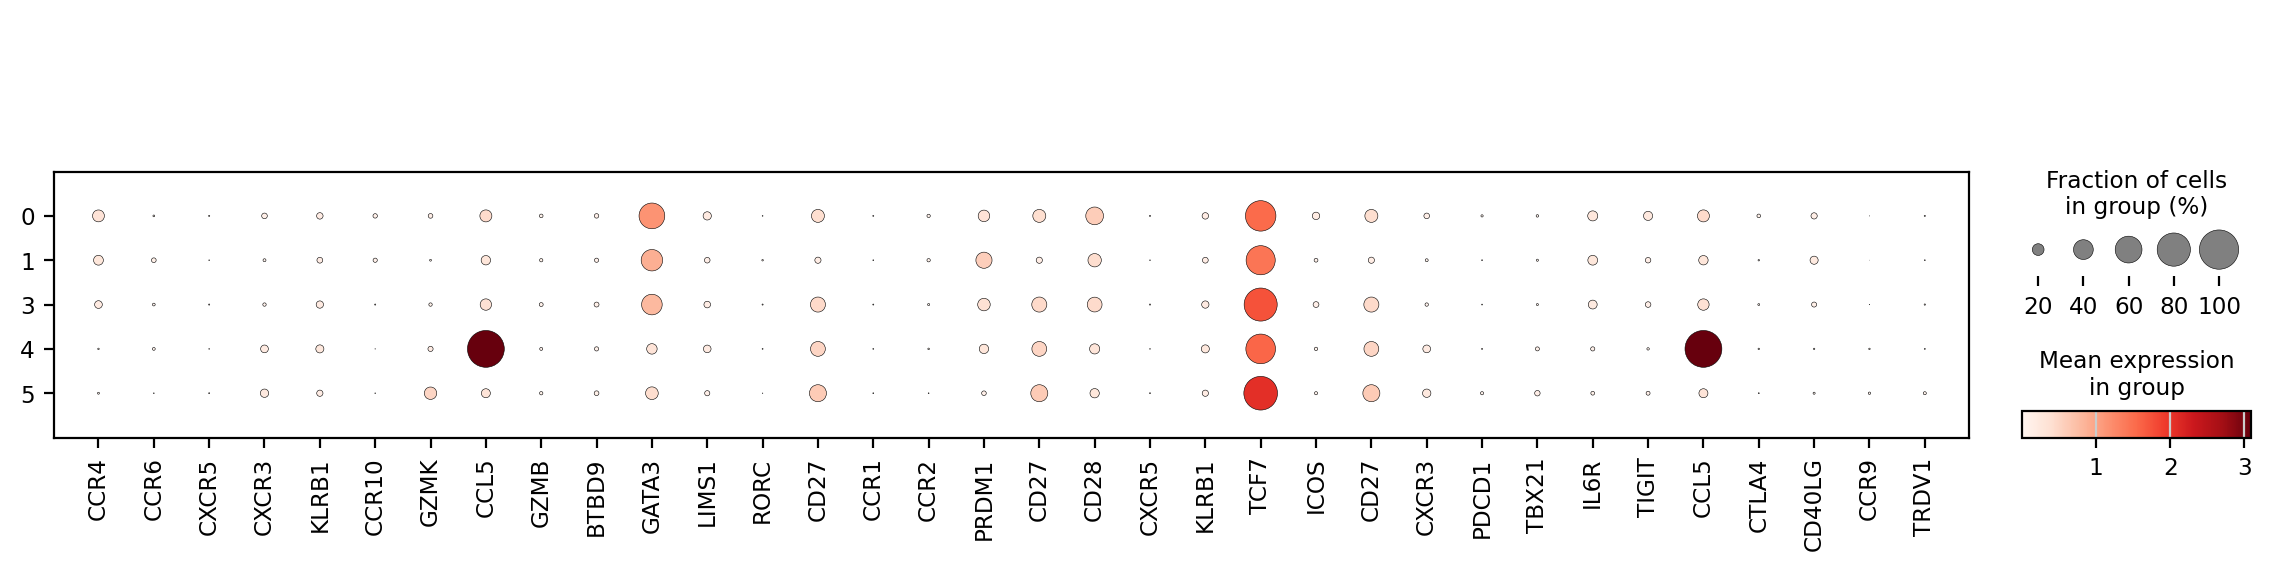

In [131]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMB','BTBD9','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','CTLA4','CD40LG','CCR9','TRDV1'],
              standard_scale='obs',groupby=groupby)

In [122]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.5
3    31744
4    18789
0    12135
1     9914
5     3999
2     1202
Name: count, dtype: int64

In [124]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−

cell_dict = {'Doublet|Lowquality':['2',],#ADT
             
             'Tcm CCR4- CCL5+ CD8+ T':['4'],#CD44 CCR4- CCL5+
             
             #CD45RA- KLRG1- TBX21- TCF7hi LEF1hi GATA3+
             #NELL2 #immunity Tcm CCR4+  TBX21- PRDM1=BLIMP1- EOMES- KLRG1-
             #CCR4+ GATA3+确认Tcm  CRIP2 GPR183  
             #immunity Tcm   PRDM1=BLIMP1+ EOMES- KLRG1-
             #分为Tcm CCR4- CCL5+ GZMKlo；Tcm CCR4+ CCL5- GZMK-； 
             'Tcm CCR4+ CCL5- CD8+ T':['0','1','3','5'],#CD44 CCR4- CCL5+

            }

In [125]:
check_dict_duplicates(cell_dict)

'无重复'

In [126]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [127]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    77783
Name: count, dtype: int64

In [128]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tcm CCR4+ CCL5- CD8+ T    57792
Tcm CCR4- CCL5+ CD8+ T    18789
Doublet|Lowquality         1202
Name: count, dtype: int64

In [129]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [132]:
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "0",:]#CD4+CD8+
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "4",:]#CD4+CD8+

In [133]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tcm CCR4+ CCL5- CD8+ T    48898
Tcm CCR4- CCL5+ CD8+ T    18573
Name: count, dtype: int64

In [134]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 10. 定 Tem CD8+ T Cell Refine

In [103]:
celltype="TemCD8"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [104]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4)

In [105]:
groupby = "L4_leiden_TOTALVI_1"

In [74]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [76]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'KLRG1',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'TRDV1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'TRDV2',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='clr')
plt.show()

In [ ]:
sc.pl.umap(adata, color='MKI67',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
adata.obs['cluster_dummy'] = adata.obs['L4_leiden_TOTALVI_1.5'] == adata.obs['L4_leiden_TOTALVI_1.5'].cat.categories[15]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['KLRF1','CD27','CD28','KLRC2','CXCR3','KLRK1','ZNF683',
                      
                      'CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMB','BTBD9','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','CTLA4','CD40LG','CCR9'],
              standard_scale='obs',groupby=groupby)

In [88]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_1
7     775394
2     673348
8     634154
0     493960
6     456800
3     386600
4     346484
12     70218
1      62702
9      48337
5       7255
13      5340
10        24
14         9
11         6
Name: count, dtype: int64

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','TRDV1'],
              standard_scale='var',groupby=groupby)

In [106]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−
#CD45RA+ CCL4 GZMK- Temra
cell_dict = {'Doublet|Lowquality':['10','11',#CSF3R
                                  '13',#low UMI
                                  ],
             
             'Cytotoxic CD4+ T':['9',],#GZMB+ 有gdT混合，但是分不开

             "Tem CD8+ T":['0','1','2','3','4','6','7','8',
                           '14'],#CD366=TIM3
             'Tcm CCR4+ CCL5- CD8+ T':['12'],
             'Proliferative CD8+ T':['5',],
            }

In [107]:
check_dict_duplicates(cell_dict)

'无重复'

In [108]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [109]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    3960631
Name: count, dtype: int64

In [110]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tem CD8+ T                3829451
Tcm CCR4+ CCL5- CD8+ T      70218
Cytotoxic CD4+ T            48337
Proliferative CD8+ T         7255
Doublet|Lowquality           5370
Name: count, dtype: int64

In [ ]:
adata.obs['L4_leiden_TOTALVI_1.5'].value_counts()

In [112]:
adata.obs.loc[adata.obs['L4_leiden_TOTALVI_1.5'] == "15",'Celltype_L3_L4_Refine'] = 'Tcm CCR4+ CCL5- CD8+ T'

In [113]:
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "3",:]#CD14
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "8",:]#CD14
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "10",:]#CD3- CSF3R+
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "22",:]#adt
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "22",:]#CD4+CD8+
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "24",:]#CD57 KLRC2
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "27",:]#XCL1/2
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "28",:]#XCL1/2
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "29",:]#ADT
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "31",:]#XCL1/2
adata = adata[adata.obs['L4_leiden_TOTALVI_1.5'] != "32",:]#CD3- CSF3R+

In [114]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [115]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tem CD8+ T                3813199
Tcm CCR4+ CCL5- CD8+ T      79093
Cytotoxic CD4+ T            48327
Proliferative CD8+ T         7249
Name: count, dtype: int64

In [117]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 11. 定 MAIT Cell Refine

In [137]:
celltype="MAIT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [138]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [139]:
groupby = "L4_leiden_TOTALVI_0.5"

In [340]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [141]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='TRAV1-2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
#sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[0,3],size=0.5)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CD3D',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'KLRB1',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'TRAV1-2',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'SLC4A10',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()

In [144]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.5
2    151134
1    138430
0     44595
3       896
4       374
Name: count, dtype: int64

In [ ]:
sc.pl.dotplot(adata, ['ISG15','JUN','FOS','IL32','TRAV1-2','SLC4A10','KLRB1','S100A4','LTB','GNLY','KLRD1','TRDV2','TRGV9'],
              standard_scale='obs',groupby=groupby,dendrogram=True)

In [ ]:
#CD185 (CXCR5) CD183 (CXCR3) CD278 (ICOS) CD279 (PD1)
sc.pl.dotplot(adt, ['CD45RA','CD197','CD62L','CD161','CD279','CD185','CD183','CD278','CD279','CD27','CD25'],
              standard_scale='obs',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMB','BTBD9','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','CTLA4','CD40LG','CCR9','FCRL6','FCRL3'],
              standard_scale='obs',groupby=groupby)

In [149]:
cell_dict={
    'Doublet|Lowquality':['3',#CD4CD8 MKI67
                          '4',#BTBD9
              ],
    'MAIT':['0','1','2'],#CD8+ TRAV1-2+ KLRB1+ SLC4A10+
}

#存在CD56- MAIT和CD56+ MAIT(8) https://www.nature.com/articles/s41590-023-01575-1#Abs1

In [150]:
check_dict_duplicates(cell_dict)

'无重复'

In [151]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [152]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    335429
Name: count, dtype: int64

In [153]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
MAIT                  334159
Doublet|Lowquality      1270
Name: count, dtype: int64

In [154]:
adata = adata[adata.obs['L4_leiden_TOTALVI_0.3'] != "1",:]#gdT
adata = adata[adata.obs['L4_leiden_TOTALVI_0.3'] != "2",:]#CD4+CD8+
adata = adata[adata.obs['L4_leiden_TOTALVI_1'] != "6",:]#CD4+CD8+

In [155]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [156]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
MAIT    320321
Name: count, dtype: int64

In [157]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 12. 定 gdT Refine

In [497]:
celltype="gdT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [498]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [180]:
groupby = "L4_leiden_TOTALVI_0.3"

In [162]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [164]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='TRDV1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='TIGIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='KLRF1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'TRDV2',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'TRGV9',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'CD3D',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD27',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='clr')
plt.show()

In [ ]:
sc.pl.dotplot(adt, ['CD27','CD45RA','CD197','CD62L','CD127','CD161','CD16','CD56'],
              groupby=groupby,dendrogram=True)

In [ ]:
sc.pl.dotplot(adata, ['TRDV2','TRGV9','TRDV1','KLRF1','TIGIT','FCGR3A','CD27','SELL','CCR7','IL7R','KLRF1','NCR1','CMC1',
                      'CCL5','TCF7','LEF1','SLC4A10','GZMK','KLRD1','KLRB1','KLRK1','BTN3A1','FCGR3A'],
              standard_scale='obs',groupby=groupby,dendrogram=True)

In [181]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
0    351787
1    300276
3    141279
5     10220
2      7129
6      5073
4      1470
Name: count, dtype: int64

In [182]:
cell_dict={
    'Vδ1 T':['5',],#CD27- KLRF1 ITGIT TRDV1 CD45RA+ CCL5+  KLRF1+ NCR1+ CMC1+
    'Vδ2 T':['0','1','2','3','4',],# CD45RA- Vγ9Vδ2 cells
    'Doublet|Lowquality':['6'],
}
#gdT 在血液中多是CD45RA- CD27+/-

# #γδ T；https://www.nature.com/articles/s41467-018-04076-0；
# https://www.nature.com/articles/s41392-023-01653-8#Sec12 #CD8+ gdT=Vδ1+  CD56+γδT存在
# Vδ2+ T cells were predominantly CD27+CD45RA−

# γδT细胞根据TCR的γ（包括2/3/4/5/8/9）和δ（包括1/2/3/5）链的表达，γδT细胞主要分为三个亚群：Vδ1T细胞，Vδ2T细胞和Vδ3T细胞。
# Vδ1T细胞主要存在于粘膜上皮细胞中，Vδ2T细胞主要分布在外周血中，Vδ3T细胞主要分布肝和肠。
# 基于CD27和CD45RA的表达差异Vδ2T细胞又分为CD45RA + CD27 +（幼稚），CD45RA-CD27 +（中间，无记忆效应功能），
# CD45RA-CD27-（记忆效应）和CD45RA + CD27-（终末分化）四群。
# 另外，γδT细胞也可分为多个功能亚群：产IFN-γ，产IL-17AγδT细胞和抗原呈递γδT细胞。

In [183]:
check_dict_duplicates(cell_dict)

'无重复'

In [184]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [185]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    817234
Name: count, dtype: int64

In [186]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Vδ2 T                 801941
Vδ1 T                  10220
Doublet|Lowquality      5073
Name: count, dtype: int64

In [187]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [188]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Vδ2 T    801941
Vδ1 T     10220
Name: count, dtype: int64

In [189]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 13. 定 ProliferativeT Cell Refine

In [442]:
celltype="ProliferativeT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [443]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [444]:
groupby = "L4_leiden_TOTALVI_1"

In [30]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              
              ]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [32]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False,layer='denoised_protein')
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='PDCD1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='TIGIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='IL2RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='KLRB1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['ISG15','CD160','KLRD1','IL2RA','CTLA4','FOXP3','FCRL3','CCR10','RORC','KLRB1','HLA-DRB1',
                     'HAVCR2'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMB','BTBD9','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','CTLA4','CD40LG'],
              standard_scale='obs',groupby=groupby)

In [445]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_1
1     4424
9     3174
10    3112
12    2757
0     2542
6     2492
5     2140
3     1883
4     1441
11     894
8      858
13     643
14     318
2      310
7      162
Name: count, dtype: int64

In [446]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

cell_dict = {
            'Proliferative Treg':['8','10','11','12'],#增殖CD38 MKI67
            'Proliferative CD8+ T':['1','3','13',],#
            'Proliferative help memory CD4+ T':['0','2','5','6','9',],#
            'Proliferative Cytotoxic CD4+ T':['14'],#
    
            'Doublet|Lowquality':['4','7'],
            }

In [447]:
check_dict_duplicates(cell_dict)

'无重复'

In [448]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [449]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    27150
Name: count, dtype: int64

In [450]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Proliferative help memory CD4+ T    10658
Proliferative Treg                   7621
Proliferative CD8+ T                 6950
Doublet|Lowquality                   1603
Proliferative Cytotoxic CD4+ T        318
Name: count, dtype: int64

In [451]:
adata = adata[adata.obs['Celltype_L3_L4_Refine'] != "Doublet|Lowquality",:]

In [452]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Proliferative help memory CD4+ T    10658
Proliferative Treg                   7621
Proliferative CD8+ T                 6950
Proliferative Cytotoxic CD4+ T        318
Name: count, dtype: int64

In [453]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R3_refine_indices_{celltype}.csv")

# 14. 定 终 Dn T Cell Refine

In [31]:
celltype="DnT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [32]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2_Refine','Celltype_L2_L3_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [33]:
groupby = "L4_leiden_TOTALVI_0.1"

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False,layer='denoised_protein')
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='FXYD2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='NUCB2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='HAVCR2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['ISG15','CD160','KLRD1','IL2RA','CTLA4','FOXP3','FCRL3','CCR10','RORC','KLRB1','HLA-DRB1',
                     'HAVCR2','CD81'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','KLRB1','CCR10','GZMK','CCL5','GZMB','BTBD9','GATA3',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5','KLRB1',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','CTLA4','CD40LG'],
              standard_scale='obs',groupby=groupby)

In [34]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.1
4    1890
0    1587
1    1471
2    1413
3    1160
Name: count, dtype: int64

In [35]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

cell_dict = {
            'DN T cells':['0','1','2','3','4'],
            }

In [36]:
check_dict_duplicates(cell_dict)

'无重复'

In [37]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [38]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    7521
Name: count, dtype: int64

In [39]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
DN T cells    7521
Name: count, dtype: int64

In [40]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,Celltype_L3_L4_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_TCTTCACA_ACCACTGT_CACCTTAC,CD4+ T,Helper memory CD4+ T,Dn T,DN T cells,DnT c0,TCR,NaN,12.806569,8.461123
D0589_Rep1_AGATGTAC_GTCGTAGA_ATAGCGAC,CD4+ T,Helper memory CD4+ T,Dn T,DN T cells,DnT c1,TCR,NaN,9.371629,2.918578
D0589_Rep1_AAGGACAC_AACAACCA_GCCACATA,CD4+ T,Helper memory CD4+ T,Dn T,DN T cells,DnT c1,TCR,NaN,10.677911,4.174545
D0589_Rep1_AAGAGATC_CAGATCTG_CTCAATGA,CD4+ T,Helper memory CD4+ T,Dn T,DN T cells,DnT c2,TCR,NaN,1.867810,-3.906549
D0589_Rep1_TGAAGAGA_CAAGACTA_GATAGACA,CD4+ T,Helper memory CD4+ T,Dn T,DN T cells,DnT c3,TCR,NaN,-3.040940,0.351439


# 21. 定 终CEACAM8_Neg_Neutrophil Refine

In [41]:
celltype="CEACAM8_Neg_Neutrophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [42]:
adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_HVG.h5ad",backed='r')
adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
adata.obsm = adt.obsm

# read Level1, tcr, bcr infor
indices = pd.read_csv(f'{obj_path}/{celltype}/R3_indices_{celltype}.csv',index_col=0)
# join leiden groups
leiden_data = adt.obs.loc[:,leiden_groups]
adata.obs = adata.obs.join(indices, how='left')
adt.obs = adt.obs.join(indices, how='left')

In [43]:
groupby = "L4_leiden_TOTALVI_0.3"

In [99]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [100]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 50000,
                                                 by = groupby,random_state=0)

In [101]:
adata_small = adata[cell_index].to_memory()

In [102]:
sc.pp.normalize_total(adata_small)
sc.pp.log1p(adata_small)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata_small, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata_small, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata_small, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata_small, keys='percent_mito', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata_small, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata_small, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata_small, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata_small, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata_small, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata_small, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [104]:
sc.tl.dendrogram(adata_small,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [105]:
#cosg差异
cosg.cosg(adata_small, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata_small.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")

In [ ]:
#cosg差异作图
df_tmp=pd.DataFrame(adata_small.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata_small.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata_small, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [107]:
sc.tl.rank_genes_groups(
            adata_small, 
            groupby=groupby,
            method='wilcoxon',
            pts=True,
            use_raw=False,  # 如果使用了归一化数据，设为False
            reference = '0',
        )

In [108]:
result = sc.get.rank_genes_groups_df(
            adata_small,
            group=None,
            pval_cutoff=0.01
        )

In [109]:
result.to_csv(f"{obj_path}{celltype}/rank_genes_groups_df_{groupby}.csv")

In [ ]:
sc.pl.rank_genes_groups_stacked_violin(adata_small, n_genes=10, cmap="viridis_r")

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata_small,
    n_genes=4,
    values_to_plot="logfoldchanges",
    min_logfoldchange=-50,
    vmax=7,
    vmin=-7,
    cmap="bwr",
)

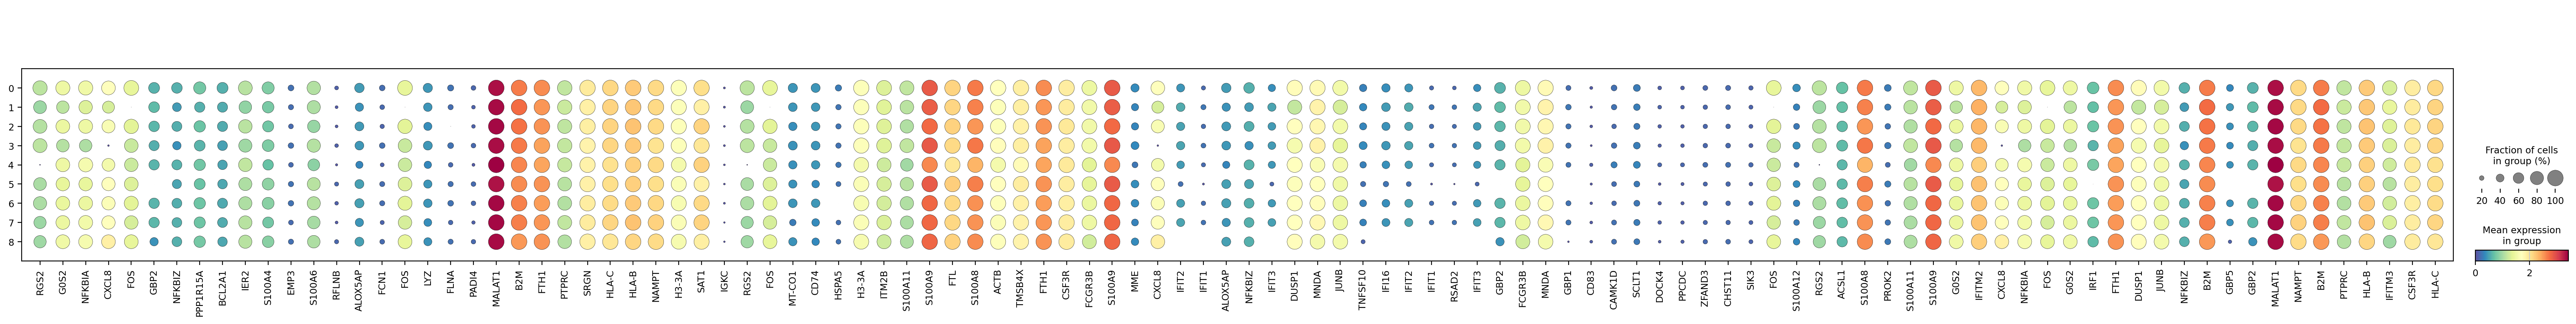

In [112]:
sc.pl.dotplot(adata_small, [
    'RGS2', 'G0S2', 'NFKBIA', 'CXCL8', 'FOS', 'GBP2', 'NFKBIZ', 'PPP1R15A', 'BCL2A1', 'IER2',
    'S100A4', 'EMP3', 'S100A6', 'RFLNB', 'ALOX5AP', 'FCN1', 'FOS', 'LYZ', 'FLNA', 'PADI4',
    'MALAT1', 'B2M', 'FTH1', 'PTPRC', 'SRGN', 'HLA-C', 'HLA-B', 'NAMPT', 'H3-3A', 'SAT1',
    'IGKC', 'RGS2', 'FOS', 'MT-CO1', 'CD74', 'HSPA5', 'H3-3A', 'ITM2B', 'S100A11',
    'S100A9', 'FTL', 'S100A8', 'ACTB', 'TMSB4X', 'FTH1', 'CSF3R', 'FCGR3B', 'S100A9',
    'MME', 'CXCL8', 'IFIT2', 'IFIT1', 'ALOX5AP', 'NFKBIZ', 'IFIT3', 'DUSP1', 'MNDA', 'JUNB',
    'TNFSF10', 'IFI16', 'IFIT2', 'IFIT1', 'RSAD2', 'IFIT3', 'GBP2', 'FCGR3B', 'MNDA', 'GBP1',
    'CD83', 'CAMK1D', 'SCLT1', 'DOCK4', 'PPCDC', 'ZFAND3', 'CHST11', 'SIK3',
    'FOS', 'S100A12', 'RGS2', 'ACSL1', 'S100A8', 'PROK2', 'S100A11', 'S100A9', 'G0S2', 'IFITM2',
    'CXCL8', 'NFKBIA', 'FOS', 'G0S2', 'IRF1', 'FTH1', 'DUSP1', 'JUNB', 'NFKBIZ', 'B2M',
    'GBP5', 'GBP2', 'MALAT1', 'NAMPT', 'B2M', 'PTPRC', 'HLA-B', 'IFITM3', 'CSF3R', 'HLA-C'],
             groupby=groupby,
             #standard_scale='var',
             cmap='Spectral_r')

In [ ]:
sc.pl.violin(adata_small, keys='S100A4', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0)

In [ ]:
sc.pl.dotplot(adata_small, ['MT-CO1','MT-CO2','MT-CO3','COX8A','MT-CYB','MT-ND1',
                      ],groupby=groupby,
              #standard_scale='var'
             )

In [ ]:
sc.pl.dotplot(adata_small, ['CD3D','IGHG4','CD274','GZMB','GNLY','CD79A','CD14','TNFAIP2','ADGRE2','SIGLEC10'
                      ],groupby=groupby,standard_scale='var')

In [ ]:
sc.pl.dotplot(adata_small, ['CSF3R','CXCR2','CXCR4','RGS2','CXCL8','IFITM1','S100A4','S100A6',
                      'EMP3','S100A8','S100A9','S100A12','S100A11',
                      'FTL','MME','SELL',
                      'TNFSF10','IFI16','ISG15','CD83',
                      'FOS','CR1','ICAM1','IRF1','GBP1','GBP2','GBP5','IRF1',
                      'GSDMD','IL1R2','HAX1',
                       'MMP9','MMP8',
                       'MPO','CD177','PADI4','CHI3L1','MKI67','NT5E','ENG','HIF1A',
                            'IL1B','IL1R1','CCL2','CCL5','TNF','IL1A','IL1B'
                      ],#standard_scale='var',
              groupby=groupby)

In [ ]:
adata_small.obs['cluster_dummy'] = adata_small.obs['Batch'] == 'B51'
sc.pl.umap(adata_small, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1)

In [ ]:
adata_small.obs['cluster_dummy'] = adata_small.obs[groupby] == adata_small.obs[groupby].cat.categories[12]
sc.pl.umap(adata_small, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1)

In [ ]:
#cosg差异作图
df_tmp=pd.DataFrame(adata_small.uns[f'cosg_{groupby}']['names'][:50,]).T
df_tmp=df_tmp.reindex(adata_small.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata_small, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
sc.pl.umap(adata_small, color=[''],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           #size=4
          )



In [ ]:
sc.pl.violin(adata_small, keys='FLNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0)

In [44]:
#都是CSF3R+(基本相同水平) CD11c+ SELL+/lo CD16+ CEACAM8- ISG15+/lo CR1+ ICAM1+
#都是CD49d- CXCR2+

#选择0.3
cell_dict = {'Core NDNs':['0'],
             'CXCL8- PTGS2+ NDNs':['3',],#确认
             'ALPL- MARCKS- NDNs':['6',],#ALPL-1 HSPA5-
             'MT-ATP6- MT-CO2- NDNs':['7'],
             'IRF1- GBP2- NDNs':['5',],#确认
             'FOS- NDNs':['1',],#确认
             'RGS2- NDNs':['4',],
             'VIM- FLNA- NDNs':['2'],
             'IFIT2- RNF213- NDNs':['8'],
            }
#CD10 和 CD62L 高低不同，活化程度不同表型
# CD35 (CR1) 和 CD54  (ICAM-1)水平升高的成熟中性粒细胞



#G-CSF 暴露导致中性粒细胞前体 (SSChi CD33/CD66b+ CD38+ CD11c− CD10−) 和未成熟中性粒细胞 (SSChi CD33/CD66b+ CD38− CD11c−/+ CD10−) 数量增加

#CXCR2/CXCL8促进出骨髓，CXCR4抑制出骨髓
#C5AR1 FPR1 ADM

#maturation: ITGAM (CD11b), FCGR3A (CD16), and MME (CD10). https://www.nature.com/articles/s41590-023-01490-5

# https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/
#  CD62Llow, CXCR2low, CXCR4hi, CD11bhi;upregulation of CXCR4 marks neutrophils for senescence;leading them back to the bone marrow for turnover.

#Degranulation, determined as an increase of the median fluorescent intensities (MFIs) of CD11b and CD66b;https://www.nature.com/articles/s41598-022-07455-2

#For mature, circulating neutrophils, a phenotype of CD16hi, CXCR2hi, CXCR4low, and CD62Lhi has been reported.

#Neutrophil profiling illuminates anti-tumor antigen-presenting potency

#黄来源：CD101区分成熟与否,但不适合



#0.5
# cell_dict = {'Core NDNs':['0','1','7'],#
#              'CXCL8- PTGS2+ NDNs':['8',],#调节作用
#              'IRF1- GBP2- GBP5- STAT1- NDNs':['5',],#II IFN 缺陷 IFN-γ 
#              'IFIT2- ISG15- MX1- RNF213- STAT1- NDNs':['6'],#I IFN 缺陷 IFN-α, IFN-β
#              'FOS- NDNs':['10',],
#              'RGS2- NDNs':['11',],
#              'VIM- FLNA- CXCL8hi GBPhi NDNs':['4'],
#              'S100A4- S100A6- NDNs':['9'],
#              'S100A4- S100A6+ NDNs':['12'],
#              'MT-CO2- CXCL8hi IRF1hi NDNs':['3'],
#              'HSPA5- ALPL- MARCKS- NDNs':['2'],
#             }

# CXCL8- NDNs 0.3的更纯
# IRF1- NDNs 0.3的更纯
# IFIT2 NDNs 0.3纯
# RNF213- NDNs 0.3纯
# MT-CO2 NDNs 0.5的更纯

# VIM的0.5和0.3相似
# FOS的0.5和0.3相似
# HSPA5的0.5和0.3相似

# S100A4- S100A6-只在0.5中有
# S100A4- S100A6+只在0.5中有

In [45]:
adata.obs[groupby].value_counts()

L4_leiden_TOTALVI_0.3
0    11531713
7     3216608
5     3043463
2     2278620
6     2254723
4     2194221
8     1407623
3     1263888
1     1209145
Name: count, dtype: int64

In [46]:
check_dict_duplicates(cell_dict)

'无重复'

In [47]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L3_L4_Refine'] = i

In [48]:
(adata.obs['Celltype_L3_L4_Refine'].isna()).value_counts()

Celltype_L3_L4_Refine
False    28400004
Name: count, dtype: int64

In [49]:
adata.obs['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Core NDNs                11531713
MT-ATP6- MT-CO2- NDNs     3216608
IRF1- GBP2- NDNs          3043463
VIM- FLNA- NDNs           2278620
ALPL- MARCKS- NDNs        2254723
RGS2- NDNs                2194221
IFIT2- RNF213- NDNs       1407623
CXCL8- PTGS2+ NDNs        1263888
FOS- NDNs                 1209145
Name: count, dtype: int64

In [50]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','Celltype_L3_L4_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,Celltype_L3_L4_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0213_Rep1_ACCTCCAA_AATGTTGC_AACAACCA,CEACAM8- Neutrophil,CEACAM8- Neutrophil,Core NDNs,Core NDNs,CEACAM8_Neg_Neutrophil c0,NaN,NaN,1.810472,15.427274
D0213_Rep1_ACAGCAGA_GCTCGGTA_ATAGCGAC,CEACAM8- Neutrophil,CEACAM8- Neutrophil,RGS2- NDNs,Core NDNs,CEACAM8_Neg_Neutrophil c0,NaN,NaN,0.991427,14.162870
D0213_Rep1_CCGAAGTA_ACACGACC_CAAGACTA,CEACAM8- Neutrophil,CEACAM8- Neutrophil,Core NDNs,Core NDNs,CEACAM8_Neg_Neutrophil c0,NaN,NaN,3.665341,13.907867
D0213_Rep1_AGTACAAG_CGCATACA_ATCATTCC,CEACAM8- Neutrophil,CEACAM8- Neutrophil,Core NDNs,Core NDNs,CEACAM8_Neg_Neutrophil c0,NaN,NaN,1.899401,13.826844
D0213_Rep1_GGAGAACA_AGCAGGAA_AATGTTGC,CEACAM8- Neutrophil,CEACAM8- Neutrophil,Core NDNs,Core NDNs,CEACAM8_Neg_Neutrophil c0,NaN,NaN,0.586281,14.421624


# 合并所有数据

## PBMC et. al.

In [29]:
try:
    del indices_dict,combined_indices,Finnal_indices_dict,combined_Finnal_indices_dict,Processing_combined_indices
except:
    print("It is None!")

It is None!


## 终版

In [98]:
celltypes=['Basophil','CEACAM8_Pos_Neutrophil','CEACAM8_Neg_Neutrophil','DnT',
           'DC','HSPC',
           'iNKT','Mast','Memory_B',
           'Monocyte','NaiveB','NaiveCD4', 'NK',
           'Non_NK_ILC','Plasma','Platelet',
]

In [99]:
Finnal_indices_dict= []
for i in tqdm(celltypes):
    indices = pd.read_csv(f'{finnal_path}{i}/Finnal_indices_{i}.csv',index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 16/16 [00:47<00:00,  2.95s/it]


In [100]:
combined_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [101]:
combined_Finnal_indices_dict['Celltype_L3_L4_Refine'].value_counts()
#本轮获得的终版细胞，合计4591075

Celltype_L3_L4_Refine
Naïve CD4+ T                   2944753
Naïve B cells                  1036706
Non-switched memory B cells     462113
Switched Memory B cells         139982
Early memory B cells            108465
Dn T                              7521
Name: count, dtype: int64

## 过程

In [102]:
%%bash
ls /home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R3/ | wc -l
ls /home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R3/*/R3_refine* | wc -l
ls /home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Finnal/ | wc -l

14
10
16


In [103]:
celltypes=['AtypicalB',
           
           'Treg',
           'CD4_helper_memory',
           'CytotoxicCD4',

           'NaiveCD8',
           'CD8Tcm',
           'TemCD8',
           'ProliferativeT',
           
           'MAIT',
           'gdT',
          ]

In [104]:
indices_dict= []
for i in tqdm(celltypes):
    indices = pd.read_csv(f'{obj_path}{i}/R3_refine_indices_{i}.csv',index_col=0)
    indices_dict.append(indices)

100%|██████████| 10/10 [00:10<00:00,  1.05s/it]


In [105]:
Processing_combined_indices = pd.concat(indices_dict)

In [106]:
combined_indices = pd.concat([Processing_combined_indices,combined_Finnal_indices_dict])

In [108]:
combined_indices['Celltype_L1_L2'].isna().value_counts()

Celltype_L1_L2
False    52574760
Name: count, dtype: int64

In [109]:
combined_indices['Celltype_L1_L2_Refine'].isna().value_counts()

Celltype_L1_L2_Refine
False    52574760
Name: count, dtype: int64

In [110]:
combined_indices['Celltype_L2_L3_Refine'].isna().value_counts()

Celltype_L2_L3_Refine
False    52574760
Name: count, dtype: int64

In [111]:
#这里Ture是上一轮已经定义的终版，合计37700538
combined_indices['Celltype_L3_L4_Refine'].isna().value_counts()

Celltype_L3_L4_Refine
True     37417894
False    15156866
Name: count, dtype: int64

In [112]:
combined_indices['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tem CD8+ T                          3813199
Naïve CD4+ T                        2944753
Naïve CD8+ T                        1252840
Tfh                                 1044618
Naïve B cells                       1036706
Cytotoxic CD4+ T                    1008739
Vδ2 T                                915369
Non-switched memory B cells          462113
Treg CD4+                            368980
Tem CD4+ T(Treg)                     333632
Th1/Th17                             328042
MAIT                                 320321
Th22                                 306766
Th17                                 224083
Switched Memory B cells              139982
Tcm CCR4+ CCL5- CD8+ T               127991
Early memory B cells                 108465
Treg(Help)                            85745
Th1                                   81038
Th2                                   77614
Atypical memory B                     64155
Vδ1 T                                 40230
Tcm CCR4- 

## save

In [113]:
def save_to_indices(celltype,celltype_to_file):
    L2_refine_path_R4 = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R4'
    indices=combined_indices['Celltype_L3_L4_Refine'].isin(celltype)
    indices_celltype=combined_indices[indices]
    print(f"{indices_celltype['Celltype_L3_L4_Refine'].value_counts()}")
    os.makedirs(f'{L2_refine_path_R4}/{celltype_to_file}', exist_ok=True)
    indices_celltype.to_csv(f"{L2_refine_path_R4}/{celltype_to_file}/R4_indices_{celltype_to_file}.csv")

In [114]:
Processing_combined_indices['Celltype_L3_L4_Refine'].value_counts()

Celltype_L3_L4_Refine
Tem CD8+ T                          3813199
Naïve CD8+ T                        1252840
Tfh                                 1044618
Cytotoxic CD4+ T                    1008739
Vδ2 T                                915369
Treg CD4+                            368980
Tem CD4+ T(Treg)                     333632
Th1/Th17                             328042
MAIT                                 320321
Th22                                 306766
Th17                                 224083
Tcm CCR4+ CCL5- CD8+ T               127991
Treg(Help)                            85745
Th1                                   81038
Th2                                   77614
Atypical memory B                     64155
Vδ1 T                                 40230
Tcm CCR4- CCL5+ CD8+ T                18573
Proliferative CD8+ T                  14199
Treg CD8+                             12595
Proliferative help memory CD4+ T      10658
Proliferative Treg                     7621
Proliferat

In [68]:
save_to_indices(celltype=['Tfh','Th1/Th17','Th22','Th17','Th1','Th2'],celltype_to_file='CD4_helper_memory')

Celltype_L3_L4_Refine
Tfh         1044618
Th1/Th17     328042
Th22         306766
Th17         224083
Th1           81038
Th2           77614
Name: count, dtype: int64


In [69]:
save_to_indices(celltype=['Cytotoxic CD4+ T'],celltype_to_file='CytotoxicCD4')

Celltype_L3_L4_Refine
Cytotoxic CD4+ T    1008739
Name: count, dtype: int64


In [70]:
save_to_indices(celltype=['Naïve CD8+ T'],celltype_to_file='NaiveCD8')
save_to_indices(celltype=['Tem CD8+ T'],celltype_to_file='TemCD8')
save_to_indices(celltype=['Tcm CCR4- CCL5+ CD8+ T','Tcm CCR4+ CCL5- CD8+ T'],celltype_to_file='CD8Tcm')

Celltype_L3_L4_Refine
Naïve CD8+ T    1252840
Name: count, dtype: int64
Celltype_L3_L4_Refine
Tem CD8+ T    3813199
Name: count, dtype: int64
Celltype_L3_L4_Refine
Tcm CCR4+ CCL5- CD8+ T    127991
Tcm CCR4- CCL5+ CD8+ T     18573
Name: count, dtype: int64


In [71]:
save_to_indices(celltype=['Vδ2 T','Vδ1 T'],celltype_to_file='gdT')

Celltype_L3_L4_Refine
Vδ2 T    915369
Vδ1 T     40230
Name: count, dtype: int64


In [72]:
save_to_indices(celltype=['Proliferative CD8+ T',
                          'Proliferative help memory CD4+ T',
                          'Proliferative Treg',
                          'Proliferative Cytotoxic CD4+ T'],celltype_to_file='ProliferativeT')

Celltype_L3_L4_Refine
Proliferative CD8+ T                14199
Proliferative help memory CD4+ T    10658
Proliferative Treg                   7621
Proliferative Cytotoxic CD4+ T        318
Name: count, dtype: int64


In [113]:
save_to_indices(celltype=['Treg CD4+','Tem CD4+ T(Treg)','Treg(Help)'],celltype_to_file='TregCD4')
save_to_indices(celltype=['Treg CD8+'],celltype_to_file='TregCD8')

Celltype_L3_L4_Refine
Treg CD4+           368980
Tem CD4+ T(Treg)    333632
Treg(Help)           85745
Name: count, dtype: int64
Celltype_L3_L4_Refine
Treg CD8+    12595
Name: count, dtype: int64


In [74]:
save_to_indices(celltype=['MAIT',],celltype_to_file='MAIT')

Celltype_L3_L4_Refine
MAIT    320321
Name: count, dtype: int64


In [75]:
save_to_indices(celltype=['Atypical memory B'],celltype_to_file='AtypicalB')

Celltype_L3_L4_Refine
Atypical memory B    64155
Name: count, dtype: int64
